# StarNet2 star / nebula extraction test

Runs the local StarNet2 CLI on `data/test_solved.fits`. The starless output is treated as the nebula layer, and `--mask` produces an additive/subtractive star layer. Float FITS data encoded as 0–255 is normalized to 0–1 automatically. Outputs are written to `data/starnet2/`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from starnet2 import extract_layers, resolve_starnet2

INPUT_PATH = Path("data/test_solved.fits")
OUTPUT_DIR = Path("data/starnet2")

# None: search the starnet2 alias, STARNET2_PATH, then known install locations.
# You can also set this explicitly to r"J:\\StarNet2\\bin\\starnet2.exe".
STARNET_EXE = None

exe = resolve_starnet2(STARNET_EXE)
print(f"StarNet2: {exe}")
print(f"Input:    {INPUT_PATH.resolve()}")
print(f"Outputs:  {OUTPUT_DIR.resolve()}")

StarNet2: J:\StarNet2\bin\starnet2.exe
Input:    J:\桌面\astro-hologram\data\test_solved.fits
Outputs:  J:\桌面\astro-hologram\data\starnet2


## Run extraction

This is the slow cell. `overwrite=True` makes repeated experiments convenient. Try `upsample=True` only if small/tight stars need extra work; it costs more time and memory.

In [2]:
result = extract_layers(
    INPUT_PATH,
    OUTPUT_DIR,
    executable=STARNET_EXE,
    output_suffix=".fits",
    overwrite=True,
    upsample=False,
    include_unscreen=False,  # True also writes the Screen-blend star layer
)

print(f"Nebula layer: {result.nebula_path}")
print(f"Star layer:   {result.stars_path}")
print(f"Input scale:  1/{result.input_scale:g}")

Normalized floating-point FITS input by 255 to the StarNet2 0..1 range.
Nebula layer: J:\桌面\astro-hologram\data\starnet2\test_solved_nebula.fits
Star layer:   J:\桌面\astro-hologram\data\starnet2\test_solved_stars.fits
Input scale:  1/255


## Compare the layers

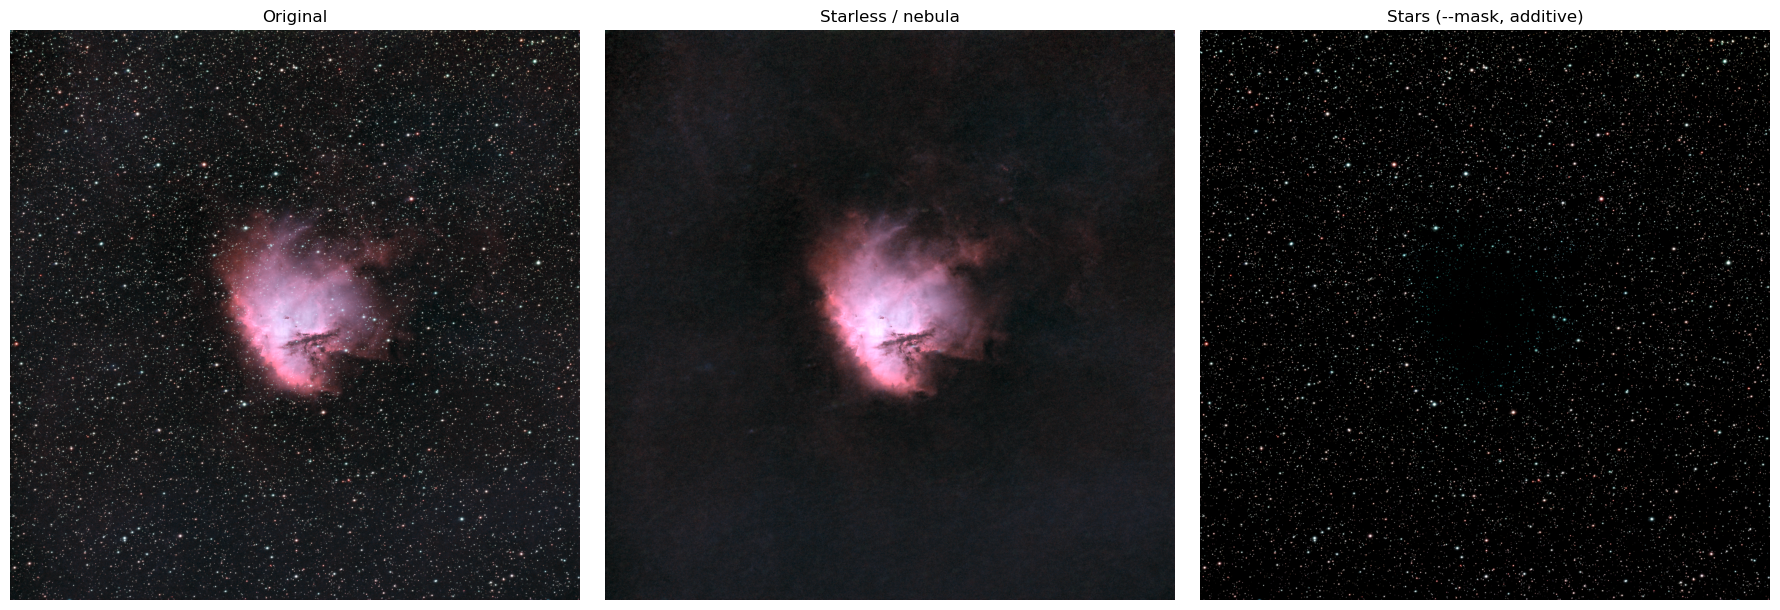

Original shape: (3, 3000, 3000)
Nebula shape:   (3, 3000, 3000)
Stars shape:    (3, 3000, 3000)


In [3]:
def load_fits_image(path):
    with fits.open(path) as hdul:
        return np.array(hdul[0].data, dtype=np.float32, copy=True)

def display_rgb(data, lower=0.5, upper=99.7):
    image = np.moveaxis(data, 0, -1) if data.ndim == 3 and data.shape[0] in (1, 3) else data
    lo, hi = np.nanpercentile(image, (lower, upper))
    return np.clip((image - lo) / max(hi - lo, 1e-12), 0, 1)

original = load_fits_image(INPUT_PATH)
nebula = load_fits_image(result.nebula_path)
stars = load_fits_image(result.stars_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, image, title in zip(
    axes,
    (original, nebula, stars),
    ("Original", "Starless / nebula", "Stars (--mask, additive)"),
):
    ax.imshow(display_rgb(image), origin="upper", cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Original shape:", original.shape)
print("Nebula shape:  ", nebula.shape)
print("Stars shape:   ", stars.shape)